In [1]:

import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download the dataset via kagglehub
kagglehub.login()
path = kagglehub.competition_download('severstal-steel-defect-detection')



Total labeled instances in train.csv: 7095


,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...



Defect Counts per Class:
ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64


C:\Users\tiob0002\AppData\Local\Temp\ipykernel_44376\1795496924.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=defect_counts.index, y=defect_counts.values, palette="viridis")


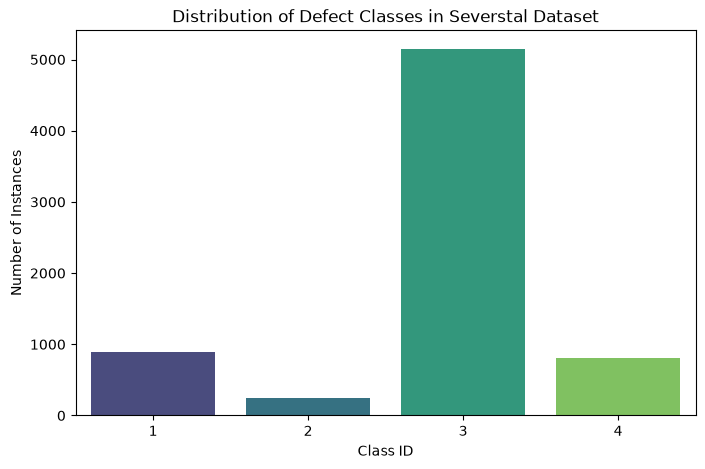


Images with at least one defect: 6666
Images with NO defects: 5902


In [2]:
csv_path = os.path.join(path, 'train.csv')
train_images_dir = os.path.join(path, 'train_images')
test_images_dir = os.path.join(path, 'test_images')

# 3. Load the dataset
train_df = pd.read_csv(csv_path)

print(f"Total labeled instances in train.csv: {len(train_df)}")
display(train_df.head())

# 4. Analyze the defect distribution
defect_counts = train_df['ClassId'].value_counts().sort_index()
print("\nDefect Counts per Class:")
print(defect_counts)

# 5. Visualize the class imbalance
plt.figure(figsize=(8, 5))
sns.barplot(x=defect_counts.index, y=defect_counts.values, palette="viridis")
plt.title('Distribution of Defect Classes in Severstal Dataset')
plt.xlabel('Class ID')
plt.ylabel('Number of Instances')
plt.show()

# Count unique images and calculate how many have NO defects (Note: train folder has ~12,568 images)
labeled_images = train_df['ImageId'].nunique()
total_train_images = len(os.listdir(train_images_dir))
print(f"\nImages with at least one defect: {labeled_images}")
print(f"Images with NO defects: {total_train_images - labeled_images}")

In [7]:
train_df['ImageId'].nunique()

6666

In [8]:
train_df['EncodedPixels'][0]

'29102 12 29346 24 29602 24 29858 24 30114 24 30370 24 30626 24 30882 24 31139 23 31395 23 31651 23 31907 23 32163 23 32419 23 32675 23 77918 27 78174 55 78429 60 78685 64 78941 68 79197 72 79452 77 79708 81 79964 85 80220 89 80475 94 80731 98 80987 102 81242 105 81498 105 81754 104 82010 104 82265 105 82521 31 82556 69 82779 27 82818 63 83038 22 83080 57 83297 17 83342 50 83555 13 83604 44 83814 8 83866 37 84073 3 84128 31 84390 25 84652 18 84918 8 85239 10 85476 29 85714 47 85960 57 86216 57 86471 58 86727 58 86983 58 87238 59 87494 59 87750 59 88005 60 88261 60 88517 60 88772 61 89028 53 89283 40 89539 32 89667 10 89795 30 89923 28 90050 29 90179 37 90306 27 90434 38 90562 14 90690 38 90817 9 90946 38 91073 3 91202 38 91458 38 91714 38 91969 39 92225 39 92481 39 92737 39 92993 39 93248 40 93504 40 93760 40 94026 30 94302 10 189792 7 190034 21 190283 28 190539 28 190795 28 191051 28 191307 28 191563 28 191819 28 192075 28 192331 28 192587 28 192843 23 193099 14 193355 5'

In [ ]:
train_df.describe()

,ClassId
count,7095.000000
mean,2.825229
std,0.789279
min,1.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,4.000000


In [9]:
train_df['ClassId'].isna().sum()

np.int64(0)

In [11]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   --------------- ------------------------ 17.0/44.0 MB 93.2 MB/s eta 0:00:01
   --------------------------------- ------ 37.0/44.0 MB 96.2 MB/s eta 0:00:01
   ---------------------------------------- 44.0/44.0 MB 84.5 MB/s  0:00:00


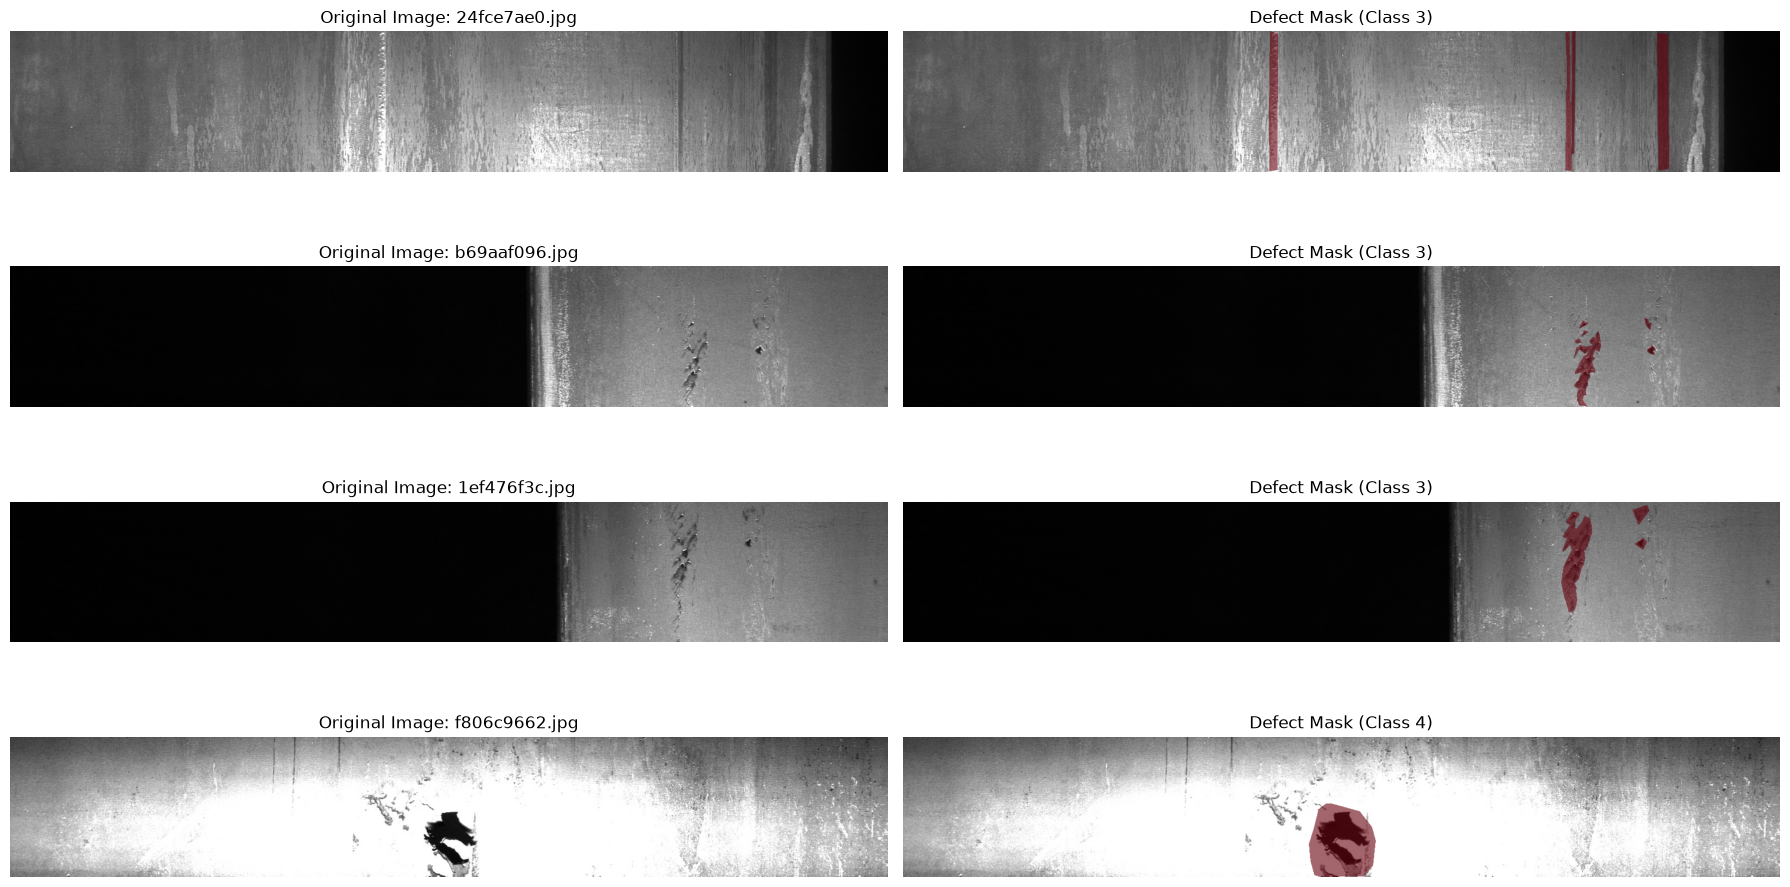

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def rle_to_mask(rle, shape=(256, 1600)):
    """Converts Run-Length Encoding string to a 2D mask array."""
    if pd.isna(rle):
        return np.zeros(shape, dtype=np.uint8)

    s = rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1  # Kaggle RLE is 1-indexed
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    # Severstal RLE is column-major (top-to-bottom, then left-to-right)
    return img.reshape(shape, order='F')

def visualize_defects(df, images_dir, num_samples=4):
    # Filter for rows that actually have defects
    defective_df = df.dropna(subset=['EncodedPixels']).sample(num_samples, random_state=42)

    fig, axes = plt.subplots(num_samples, 2, figsize=(18, 2.5 * num_samples))

    for idx, (_, row) in enumerate(defective_df.iterrows()):
        img_id = row['ImageId']
        class_id = row['ClassId']
        rle = row['EncodedPixels']

        # Read image
        img_path = os.path.join(images_dir, img_id)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Generate mask
        mask = rle_to_mask(rle)

        # Plot Original Image
        axes[idx, 0].imshow(img, cmap='gray')
        axes[idx, 0].set_title(f'Original Image: {img_id}')
        axes[idx, 0].axis('off')

        # Plot Mask Overlay
        axes[idx, 1].imshow(img, cmap='gray')
        # Overlay the mask in red where defect exists
        axes[idx, 1].imshow(np.ma.masked_where(mask == 0, mask), alpha=0.6, cmap='Reds', vmin=0, vmax=1)
        axes[idx, 1].set_title(f'Defect Mask (Class {class_id})')
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize 4 random defective samples
visualize_defects(train_df, train_images_dir, num_samples=4)

In [4]:
from sklearn.model_selection import train_test_split

# 1. Grab all image filenames to ensure we capture the defect-free background images
all_images = pd.DataFrame({'ImageId': os.listdir(train_images_dir)})

# 2. Pivot the training labels so we have one row per image with columns for each class mask
pivot_df = train_df.pivot(index='ImageId', columns='ClassId', values='EncodedPixels').reset_index()
pivot_df.columns = ['ImageId', 'rle_1', 'rle_2', 'rle_3', 'rle_4']

display(pivot_df.head())

# 3. Merge to create the master dataset
master_df = all_images.merge(pivot_df, on='ImageId', how='left')

display(master_df)

# 4. Create binary flags for each class (1 if defect present, 0 if not)
for i in range(1, 5):
    master_df[f'class_{i}'] = master_df[f'rle_{i}'].notna().astype(int)

master_df['defect_count'] = master_df[['class_1', 'class_2', 'class_3', 'class_4']].sum(axis=1)
master_df['has_defect'] = (master_df['defect_count'] > 0).astype(int)

# 5. Create a strict stratification key based on the exact defect profile
master_df['stratify_key'] = (
    master_df['class_1'].astype(str) +
    master_df['class_2'].astype(str) +
    master_df['class_3'].astype(str) +
    master_df['class_4'].astype(str)
)

# train_test_split fails if a class has fewer than 2 instances.
# Group any ultra-rare combinations into a fallback category.
key_counts = master_df['stratify_key'].value_counts()
rare_keys = key_counts[key_counts < 2].index
master_df.loc[master_df['stratify_key'].isin(rare_keys), 'stratify_key'] = 'rare_combo'

# 6. Perform the 80/20 Stratified Split
train_split, val_split = train_test_split(
    master_df,
    test_size=0.2,
    random_state=42,
    stratify=master_df['stratify_key']
)

# Reset indexes for clean iteration later
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

print(f"Training set: {len(train_split)} images")
print(f"Validation set: {len(val_split)} images")

print("\n--- Defect Distribution in Train ---")
print(train_split[['class_1', 'class_2', 'class_3', 'class_4', 'has_defect']].sum())

print("\n--- Defect Distribution in Validation ---")
print(val_split[['class_1', 'class_2', 'class_3', 'class_4', 'has_defect']].sum())

,ImageId,rle_1,rle_2,rle_3,rle_4
0,0002cc93b.jpg,29102 12 29346 24 29602 24 29858 24 30114 24 3...,NaN,NaN,NaN
1,0007a71bf.jpg,NaN,NaN,18661 28 18863 82 19091 110 19347 110 19603 11...,NaN
2,000a4bcdd.jpg,37607 3 37858 8 38108 14 38359 20 38610 25 388...,NaN,NaN,NaN
3,000f6bf48.jpg,NaN,NaN,NaN,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,NaN,NaN,229501 11 229741 33 229981 55 230221 77 230468...,NaN


,ImageId,rle_1,rle_2,rle_3,rle_4
0,0002cc93b.jpg,29102 12 29346 24 29602 24 29858 24 30114 24 3...,NaN,NaN,NaN
1,00031f466.jpg,NaN,NaN,NaN,NaN
2,000418bfc.jpg,NaN,NaN,NaN,NaN
3,000789191.jpg,NaN,NaN,NaN,NaN
4,0007a71bf.jpg,NaN,NaN,18661 28 18863 82 19091 110 19347 110 19603 11...,NaN
...,...,...,...,...,...
12563,fff0295e1.jpg,NaN,NaN,NaN,NaN
12564,fff02e9c5.jpg,NaN,NaN,207523 3 207777 9 208030 15 208283 22 208537 2...,NaN
12565,fffe98443.jpg,NaN,NaN,105929 5 106177 14 106424 24 106672 33 106923 ...,NaN
12566,ffff4eaa8.jpg,NaN,NaN,16899 7 17155 20 17411 34 17667 47 17923 60 18...,NaN


ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: ['rare_combo']

In [14]:
!pip install -q iterative-stratification

In [5]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# 1. Grab all image filenames
all_images = pd.DataFrame({'ImageId': os.listdir(train_images_dir)})

# 2. Pivot the training labels
pivot_df = train_df.pivot(index='ImageId', columns='ClassId', values='EncodedPixels').reset_index()
pivot_df.columns = ['ImageId', 'rle_1', 'rle_2', 'rle_3', 'rle_4']

# 3. Merge to create the master dataset
master_df = all_images.merge(pivot_df, on='ImageId', how='left')

# 4. Create binary flags for each class (1 if defect present, 0 if not)
for i in range(1, 5):
    master_df[f'class_{i}'] = master_df[f'rle_{i}'].notna().astype(int)

display(master_df.head())
# Explicitly flag defect-free images so the stratifier balances them across folds
master_df['no_defect'] = (master_df[['class_1', 'class_2', 'class_3', 'class_4']].sum(axis=1) == 0).astype(int)

# 5. Extract the target matrix for multi-label stratification
targets = master_df[['class_1', 'class_2', 'class_3', 'class_4', 'no_defect']].values

# 6. Apply 5-Fold Multilabel Stratified Split
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
master_df['fold'] = -1

for fold_idx, (train_idx, val_idx) in enumerate(mskf.split(X=master_df, y=targets)):
    master_df.loc[val_idx, 'fold'] = fold_idx

# 7. Verify the distribution across folds
print("--- Defect Distribution Across Folds ---")
fold_stats = master_df.groupby('fold')[['class_1', 'class_2', 'class_3', 'class_4', 'no_defect']].sum()
display(fold_stats)

# 8. Set up our active train/val split using Fold 0 for validation
train_split = master_df[master_df['fold'] != 0].reset_index(drop=True)
val_split = master_df[master_df['fold'] == 0].reset_index(drop=True)

print(f"\nTraining set (Folds 1-4): {len(train_split)} images")
print(f"Validation set (Fold 0): {len(val_split)} images")

,ImageId,rle_1,rle_2,rle_3,rle_4,class_1,class_2,class_3,class_4
0,0002cc93b.jpg,29102 12 29346 24 29602 24 29858 24 30114 24 3...,NaN,NaN,NaN,1,0,0,0
1,00031f466.jpg,NaN,NaN,NaN,NaN,0,0,0,0
2,000418bfc.jpg,NaN,NaN,NaN,NaN,0,0,0,0
3,000789191.jpg,NaN,NaN,NaN,NaN,0,0,0,0
4,0007a71bf.jpg,NaN,NaN,18661 28 18863 82 19091 110 19347 110 19603 11...,NaN,0,0,1,0


--- Defect Distribution Across Folds ---


,class_1,class_2,class_3,class_4,no_defect
fold,,,,,
0,179,49,1030,161,1180
1,180,49,1030,160,1180
2,180,50,1030,160,1181
3,179,49,1030,160,1180
4,179,50,1030,160,1181



Training set (Folds 1-4): 10058 images
Validation set (Fold 0): 2510 images


In [27]:
%pip install --user albumentations

Note: you may need to restart the kernel to use updated packages.


In [21]:
!pip install albumentations

In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class SeverstalDataset(Dataset):
    def __init__(self, df, data_folder, transforms=None, cache_in_ram=False):
        self.df = df.reset_index(drop=True)
        self.data_folder = data_folder
        self.transforms = transforms
        self.cache_in_ram = cache_in_ram
        # Memory Map / Shared RAM Caching
        self.image_cache = {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row['ImageId']

        # 1. Load Image (with optional RAM caching)
        if self.cache_in_ram and image_id in self.image_cache:
            image = self.image_cache[image_id]
        else:
            image_path = os.path.join(self.data_folder, image_id)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            if self.cache_in_ram:
                self.image_cache[image_id] = image

        # 2. Build 4-Channel Mask
        # We assume the `rle_to_mask` function from the previous cell is defined
        masks = np.zeros((256, 1600, 4), dtype=np.float32)
        for i in range(1, 5):
            rle = row[f'rle_{i}']
            if pd.notna(rle):
                masks[:, :, i-1] = rle_to_mask(rle, shape=(256, 1600))

        # 3. Apply Transformations & Dynamic Cropping
        if self.transforms:
            augmented = self.transforms(image=image, mask=masks)
            image = augmented['image']
            masks = augmented['mask']

        return image, masks

# --- Data Augmentation & Dynamic Crop Pipeline ---
# Train: Crop dynamically around defects, apply flips/color jitter
train_transforms = A.Compose([
    # Dynamic Crop: Forces the crop to include a defect if one exists, otherwise random crop
    A.CropNonEmptyMaskIfExists(height=256, width=512, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True) # Converts mask to (C, H, W)
])

# Validation: Center crop or resize (using resize here for whole-image evaluation)
val_transforms = A.Compose([
    A.Resize(height=256, width=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True)
])

# --- Instantiate Datasets ---
# Note: Set cache_in_ram=False for standard Colab to prevent OOM crashes.
# Set to True only if using Colab Pro with High-RAM.
train_dataset = SeverstalDataset(train_split, train_images_dir, transforms=train_transforms, cache_in_ram=False)
val_dataset = SeverstalDataset(val_split, train_images_dir, transforms=val_transforms, cache_in_ram=False)

# --- Optimized DataLoaders ---
BATCH_SIZE = 16
NUM_WORKERS = 4      # Maps to 4-8 CPU threads
PREFETCH_FACTOR = 2  # GPU Prefetch buffer

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,          # Accelerates CPU-to-GPU memory transfer
    prefetch_factor=PREFETCH_FACTOR,
    drop_last=True            # Keeps batches consistent for batch normalization
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=PREFETCH_FACTOR
)

# Test the pipeline
images, masks = next(iter(train_loader))
print(f"Batch Image tensor shape: {images.shape} (B, C, H, W)")
print(f"Batch Mask tensor shape: {masks.shape} (B, C, H, W)")

In [25]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss

# --- 1. Streamlined Dataset for Stage 1 ---
# Skips mask loading completely for maximum I/O speed
class ClassifierDataset(Dataset):
    def __init__(self, df, data_folder, transforms=None):
        self.df = df.reset_index(drop=True)
        self.data_folder = data_folder
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row['ImageId']

        # Binary target: 1.0 for defect, 0.0 for clean
        label = torch.tensor([row['has_defect']], dtype=torch.float32)

        image_path = os.path.join(self.data_folder, image_id)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented['image']

        return image, label

# Stage 1 Augmentations (No masks to transpose)
clf_train_transforms = A.Compose([
    A.RandomCrop(height=256, width=512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

clf_val_transforms = A.Compose([
    A.Resize(height=256, width=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Initialize DataLoaders for Stage 1
clf_train_loader = DataLoader(
    ClassifierDataset(train_split, train_images_dir, transforms=clf_train_transforms),
    batch_size=32, shuffle=True, num_workers=4, pin_memory=True
)
clf_val_loader = DataLoader(
    ClassifierDataset(val_split, train_images_dir, transforms=clf_val_transforms),
    batch_size=32, shuffle=False, num_workers=4, pin_memory=True
)

# --- 2. Lightweight ResNet34 Backbone ---
class BinaryDefectClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super(BinaryDefectClassifier, self).__init__()
        # Load standard ResNet34
        self.backbone = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None)

        # Replace the final fully connected layer for binary classification (1 output node)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

# --- 3. Initialize Model, Loss, and Optimizer ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classifier_model = BinaryDefectClassifier(pretrained=True).to(device)

# BCEWithLogitsLoss combines a Sigmoid layer and the BCELoss in one single class for numerical stability
criterion = BCEWithLogitsLoss()
optimizer = AdamW(classifier_model.parameters(), lr=1e-4, weight_decay=1e-3)

print(f"Model initialized on {device}.")
print(f"Total trainable parameters: {sum(p.numel() for p in classifier_model.parameters() if p.requires_grad):,}")

ModuleNotFoundError: No module named 'albumentations'

In [26]:
!pip install -q segmentation-models-pytorch

import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. Initialize U-Net ---
# ResNet34 strikes the best balance between VRAM footprint and feature extraction depth
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = 4      # 4 defect types
ACTIVATION = None # We output raw logits and apply Sigmoid inside the loss function for stability

segmentation_model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    classes=CLASSES,
    activation=ACTIVATION,
).to(device)

# --- 2. Custom BCE + Dice Loss ---
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        # BCEWithLogitsLoss combines Sigmoid + BCE safely
        self.bce = nn.BCEWithLogitsLoss()
        # SMP's DiceLoss natively supports multi-label inputs from raw logits
        self.dice = smp.losses.DiceLoss(mode='multilabel', from_logits=True)

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        dice_loss = self.dice(inputs, targets)
        return (self.bce_weight * bce_loss) + (self.dice_weight * dice_loss)

criterion_seg = BCEDiceLoss(bce_weight=0.4, dice_weight=0.6) # Slight bias toward Dice for rare defects
optimizer_seg = AdamW(segmentation_model.parameters(), lr=5e-4, weight_decay=1e-4)

print(f"Stage 2 U-Net initialized on {device}.")
print(f"Total trainable parameters: {sum(p.numel() for p in segmentation_model.parameters() if p.requires_grad):,}")

# --- 3. Sanity Check Forward Pass ---
print("\nTesting Stage 2 Forward Pass (requires train_loader from earlier cell)...")
# Note: Ensure train_loader from the SeverstalDataset is in memory
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

# Forward pass
logits = segmentation_model(images)
loss = criterion_seg(logits, masks)

print(f"Input image shape: {images.shape}")
print(f"Ground truth mask shape: {masks.shape}")
print(f"Model output logits shape: {logits.shape}")
print(f"Calculated combined loss: {loss.item():.4f}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

C:\Users\tiob0002\AppData\Local\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tiob0002\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\tiob0002\AppData\Local\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:149: 

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Stage 2 U-Net initialized on cuda.
Total trainable parameters: 24,436,804

Testing Stage 2 Forward Pass (requires train_loader from earlier cell)...


NameError: name 'train_loader' is not defined

In [ ]:
import torch
import numpy as np
from tqdm.auto import tqdm

# --- 1. Dice Coefficient Metric ---
def dice_coef_metric(y_pred_logits, y_true, threshold=0.5, eps=1e-7):
    """
    Computes the mean Dice coefficient across all classes and batch items.
    """
    # Apply sigmoid to get probabilities, then threshold to get binary masks
    probabilities = torch.sigmoid(y_pred_logits)
    preds = (probabilities > threshold).float()

    # Flatten the spatial dimensions: (B, C, H, W) -> (B, C, H*W)
    b, c, h, w = preds.shape
    preds = preds.view(b, c, -1)
    truth = y_true.view(b, c, -1)

    # Calculate intersection and union per channel, per image
    intersection = (preds * truth).sum(dim=2)
    union = preds.sum(dim=2) + truth.sum(dim=2)

    # Calculate Dice per channel, per image
    dice = (2.0 * intersection + eps) / (union + eps)

    # Return the mean Dice score across the entire batch
    return dice.mean().item()

# --- 2. Integrated Training Loop ---
EPOCHS = 15
best_val_dice = 0.0
model_save_path = "unet_resnet34_best.pth"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 20)

    # --- TRAINING PHASE ---
    segmentation_model.train()
    train_loss = 0.0

    # Wrap dataloader in tqdm for a progress bar
    train_pbar = tqdm(train_loader, desc="Training", leave=False)

    for images, masks in train_pbar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer_seg.zero_grad()

        # Forward pass
        logits = segmentation_model(images)
        loss = criterion_seg(logits, masks)

        # Backward pass & Optimization
        loss.backward()
        optimizer_seg.step()

        train_loss += loss.item()
        train_pbar.set_postfix({'loss': loss.item()})

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    segmentation_model.eval()
    val_loss = 0.0
    val_dice = 0.0

    val_pbar = tqdm(val_loader, desc="Validation", leave=False)

    # Disable gradient calculation for validation to save memory/compute
    with torch.no_grad():
        for images, masks in val_pbar:
            images = images.to(device)
            masks = masks.to(device)

            logits = segmentation_model(images)
            loss = criterion_seg(logits, masks)

            val_loss += loss.item()
            val_dice += dice_coef_metric(logits, masks, threshold=0.5)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

    # --- CHECKPOINTING ---
    if avg_val_dice > best_val_dice:
        print(f"Validation Dice improved from {best_val_dice:.4f} to {avg_val_dice:.4f}. Saving model...")
        best_val_dice = avg_val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': segmentation_model.state_dict(),
            'optimizer_state_dict': optimizer_seg.state_dict(),
            'val_dice': best_val_dice
        }, model_save_path)

In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. Mask to RLE Encoder ---
def mask_to_rle(mask):
    """
    Converts a 2D binary numpy array to Kaggle's Run-Length Encoding format.
    Severstal uses column-major (Fortran) indexing, 1-based.
    """
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

# --- 2. Test Dataset ---
class TestDataset(Dataset):
    def __init__(self, data_folder, transforms=None):
        self.data_folder = data_folder
        self.image_files = os.listdir(data_folder)
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_id = self.image_files[idx]
        image_path = os.path.join(self.data_folder, image_id)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented['image']

        return image, image_id

# Use the same transforms as validation (Resize to 512 width for the models)
test_transforms = A.Compose([
    A.Resize(height=256, width=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

test_dataset = TestDataset(test_images_dir, transforms=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

# --- 3. Two-Stage Inference Loop ---
classifier_model.eval()
segmentation_model.eval()

submission_data = []

# Thresholds
CLASSIFIER_THRESH = 0.5
SEGMENTATION_THRESH = 0.5

print("Starting Two-Stage Inference...")
with torch.no_grad():
    for images, image_ids in tqdm(test_loader, desc="Predicting Test Set"):
        images = images.to(device)

        # 1. Fast-Pass: Binary Classifier
        clf_logits = classifier_model(images)
        clf_probs = torch.sigmoid(clf_logits).squeeze(1) # Shape: (Batch,)

        # Identify which images in the batch actually have defects
        has_defect_mask = clf_probs > CLASSIFIER_THRESH

        # 2. Setup blank predictions for the entire batch
        batch_size = images.size(0)
        batch_rles = {img_id: ["", "", "", ""] for img_id in image_ids}

        # 3. Route defective images to the Segmentation Model
        if has_defect_mask.any():
            # Filter the batch for only defective images
            defective_images = images[has_defect_mask]
            defective_ids = [image_ids[i] for i in range(batch_size) if has_defect_mask[i].item()]

            # Forward pass through U-Net
            seg_logits = segmentation_model(defective_images)
            seg_probs = torch.sigmoid(seg_logits) # Shape: (Defective_Batch, 4, 256, 512)

            # Convert probabilities to binary masks
            seg_preds = (seg_probs > SEGMENTATION_THRESH).cpu().numpy().astype(np.uint8)

            # Process and resize masks back to original 256x1600 resolution
            for i, img_id in enumerate(defective_ids):
                for class_idx in range(4):
                    mask_512 = seg_preds[i, class_idx, :, :]

                    # Only calculate RLE if the mask actually contains predicted defects
                    if mask_512.sum() > 0:
                        # Resize back up to 1600px width using Nearest Neighbor to keep it binary
                        mask_1600 = cv2.resize(mask_512, (1600, 256), interpolation=cv2.INTER_NEAREST)
                        batch_rles[img_id][class_idx] = mask_to_rle(mask_1600)

        # 4. Format for Kaggle Submission
        for img_id in image_ids:
            for class_idx in range(4):
                submission_data.append({
                    'ImageId_ClassId': f"{img_id}_{class_idx + 1}",
                    'EncodedPixels': batch_rles[img_id][class_idx]
                })

# --- 4. Save Submission ---
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv('submission.csv', index=False)

print(f"\nInference complete. Generated {len(submission_df)} rows.")
print("Saved to submission.csv. You are ready to submit to Kaggle!")
display(submission_df.head(10))